# Depth-Anything-V2: Metric Depth Evaluation Across Implementations

This notebook evaluates **Depth-Anything-V2 metric depth estimation** using three inference implementations under the same controlled experimental setup:

1. **Official Depth-Anything-V2 repository** using the original PyTorch implementation and metric checkpoint.
2. **Hugging Face Transformers** using a metric-depth model.
3. **4-bit quantized Hugging Face inference** using BitsAndBytes for memory-constrained deployment.

The purpose is to compare **metric accuracy, spatial consistency, inference time, and implementation-level trade-offs** rather than only visualize depth maps.

The evaluation uses **59 synchronized RGB-depth pairs captured with an Intel RealSense depth camera in a real indoor lab environment**. The RGB frame is the sole input to every model; the RealSense depth map is dense, per-pixel ground truth that is never passed to the models and is only used after inference to score the predictions.

This is a controlled validation study, not a replacement for established dense-depth benchmarks such as NYUv2 or KITTI.


## Experimental Design

The same RGB frame is passed through all implementations. The RealSense depth map for that frame is **dense, per-pixel ground truth** — it is captured by the depth sensor at acquisition time and is used only after inference, never as model input.

Depth is stored on disk as 16-bit PNGs in millimeters and is converted to meters with a scale factor of `0.001`. Zero-valued pixels in the RealSense depth map represent invalid/unmeasured returns (e.g. reflective, transparent, or out-of-range surfaces) and are excluded from every metric.

Because ground truth is now a full depth map rather than a single measured distance, evaluation is done **pixel-wise** over the valid, overlapping region between the prediction and the RealSense depth map, in addition to an image-level summary based on the median depth.

The evaluation reports, per frame and per implementation:

- MAE (m)
- RMSE (m)
- Abs Rel (%) — mean absolute relative error
- Median depth error (m)
- Predicted depth standard deviation (m)
- Mean inference latency

The test set consists of **59 real RGB-depth pairs** captured with an Intel RealSense camera in a lab environment. Additional captures can be added by dropping more pairs into the same `color/` and `depth/` folders before re-zipping and re-uploading the dataset.


In [ ]:
!git clone -q https://github.com/DepthAnything/Depth-Anything-V2
%cd Depth-Anything-V2/metric_depth
!pip install -q -r requirements.txt
!pip install -q bitsandbytes accelerate transformers huggingface_hub matplotlib pandas

/content/Depth-Anything-V2/metric_depth
ERROR: Could not find a version that satisfies the requirement open3d (from versions: none)
ERROR: No matching distribution found for open3d
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 16.5 MB/s eta 0:00:00


In [ ]:
import time
import gc
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
from PIL import Image
from huggingface_hub import hf_hub_download

from depth_anything_v2.dpt import DepthAnythingV2
from transformers import AutoImageProcessor, AutoModelForDepthEstimation, BitsAndBytesConfig


## Dataset Configuration

The dataset is **59 synchronized RGB-depth pairs** captured with an Intel RealSense depth camera in a real indoor lab environment, packaged as a single zip archive and hosted on the public Hugging Face dataset repository so the experiment is not tied to a local filesystem.

The archive contains a `color/` folder of RGB PNGs and a `depth/` folder of matching 16-bit RealSense depth PNGs (values in millimeters), with each pair sharing the same filename stem. The zip is downloaded and extracted once, and the two folders are checked for alignment before any inference is run.

The RealSense depth maps are **never passed to the models** — they are loaded only when scoring predictions.


In [ ]:
HF_REPO = "WasiqSaleem/Portfolio_Assets"
HF_REPO_TYPE = "dataset"
ZIP_NAME = "testing_env_spec_real_camera_dataset_combined.zip"
DATASET_FOLDER = "testing_env_spec_real_camera_dataset_combined"  # top-level folder inside the zip
COLOR_SUBDIR = "color"
DEPTH_SUBDIR = "depth"

# RealSense depth PNGs are stored in millimeters -> convert to meters.
DEPTH_UNITS_TO_METERS = 0.001

In [ ]:
zip_path = hf_hub_download(
    repo_id=HF_REPO,
    filename=ZIP_NAME,
    repo_type=HF_REPO_TYPE,
    local_dir="/content"
)

extract_root = Path("/content")
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_root)

dataset_root = extract_root / DATASET_FOLDER
color_dir = dataset_root / COLOR_SUBDIR
depth_dir = dataset_root / DEPTH_SUBDIR

color_paths = sorted(color_dir.glob("*.png"))
depth_paths = sorted(depth_dir.glob("*.png"))

assert len(color_paths) == len(depth_paths), (
    f"Mismatched pair counts: {len(color_paths)} color vs {len(depth_paths)} depth"
)
assert all(c.stem == d.stem for c, d in zip(color_paths, depth_paths)), (
    "Color and depth filenames are not aligned by stem."
)

print(f"Found {len(color_paths)} aligned RGB-depth pairs.")


testing_env_spec_real_camera_dataset_com(…): reconstructing file:   0%|          |  0.00B / 26.9MB            

testing_env_spec_real_camera_dataset_com(…): downloading bytes:           |  0.00B            

Found 59 aligned RGB-depth pairs.


In [ ]:
available_cases = []

for color_path, depth_path in zip(color_paths, depth_paths):
    image = Image.open(color_path).convert("RGB")

    available_cases.append({
        "image_number": color_path.stem,
        "filename": color_path.name,
        "image_path": color_path,
        "depth_path": depth_path,
        "image": image
    })

print(f"Loaded {len(available_cases)} RGB-depth pairs.")

sample_case = available_cases[0]
raw_depth = np.array(Image.open(sample_case["depth_path"]), dtype=np.float32)
converted_depth = raw_depth * DEPTH_UNITS_TO_METERS
valid_converted = converted_depth[converted_depth > 0]

print(f"Sample frame: {sample_case['image_number']}")
print(f"Raw depth range (mm): {raw_depth.min():.0f} - {raw_depth.max():.0f}")
print(
    f"Converted depth range (m, valid pixels only): "
    f"{valid_converted.min():.3f} - {valid_converted.max():.3f}"
)


Loaded 59 RGB-depth pairs.
Sample frame: 00000
Raw depth range (mm): 0 - 6592
Converted depth range (m, valid pixels only): 1.514 - 6.592


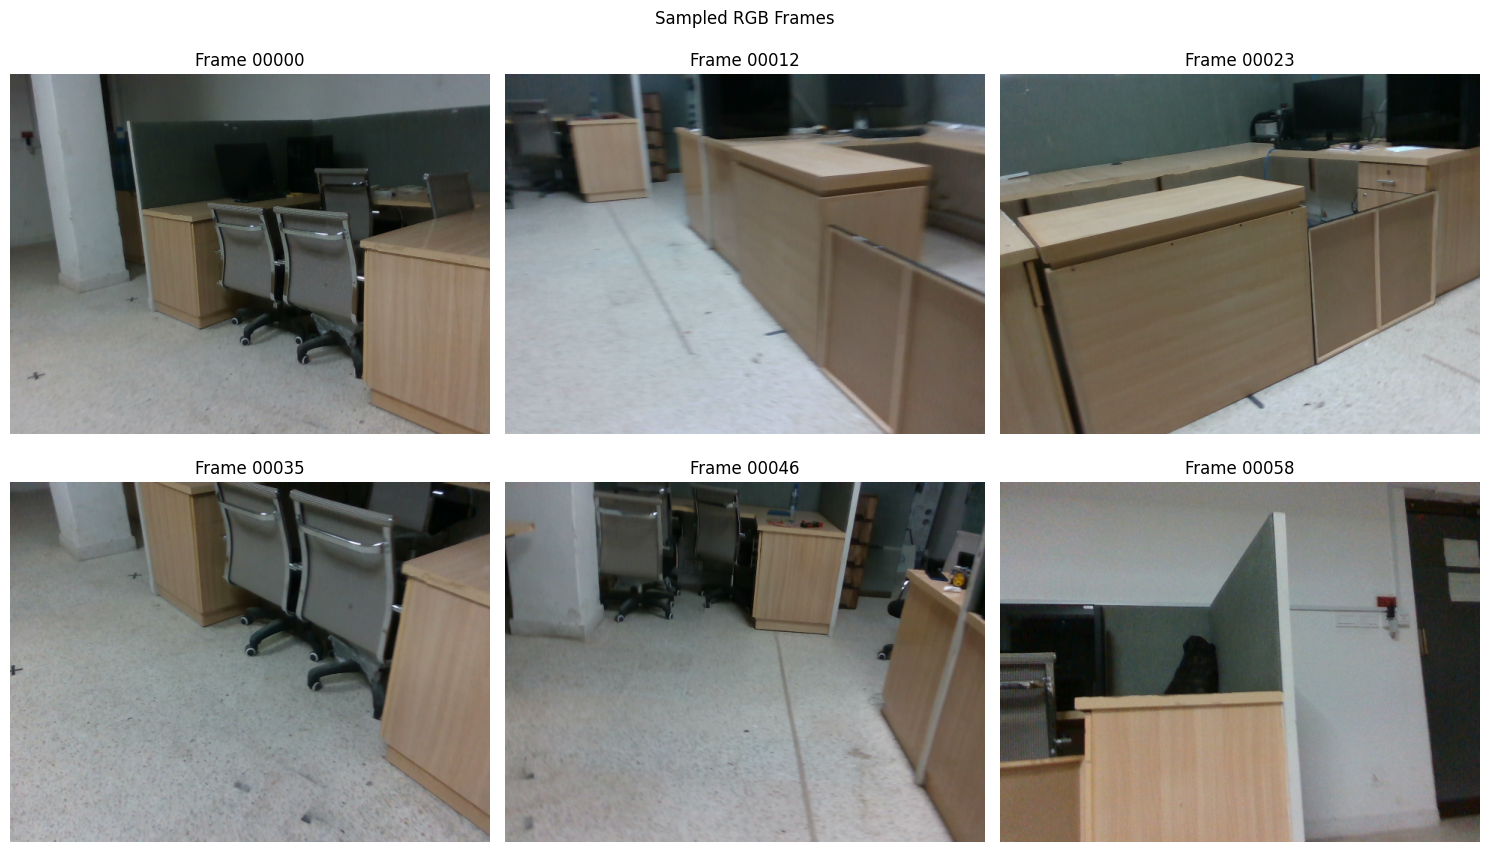

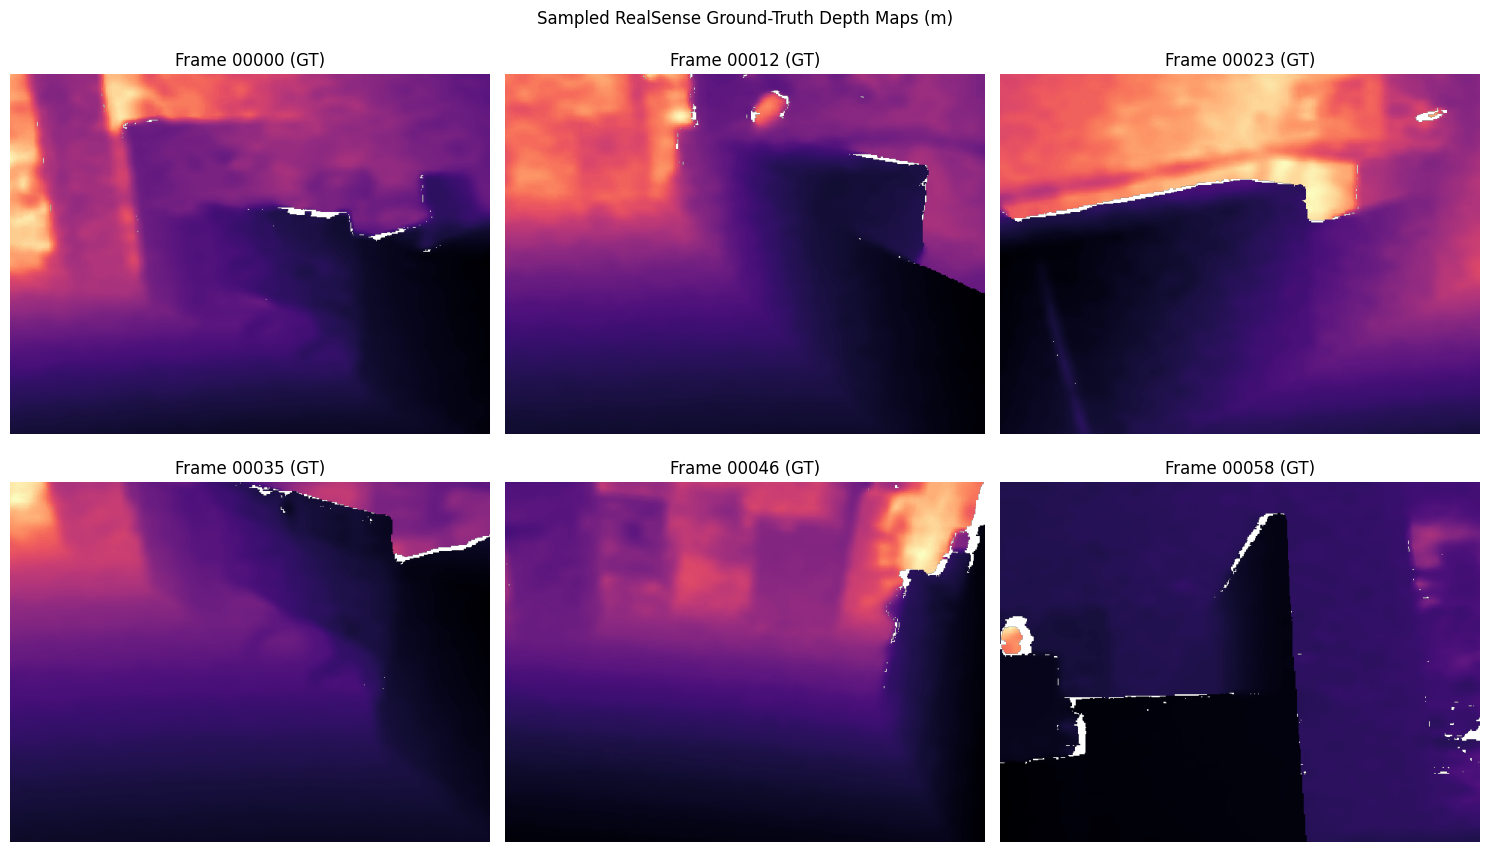

In [ ]:
sample_indices = np.linspace(0, len(available_cases) - 1, 6).round().astype(int)
sample_cases = [available_cases[i] for i in sample_indices]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, case in zip(axes.ravel(), sample_cases):
    ax.imshow(case["image"])
    ax.set_title(f"Frame {case['image_number']}")
    ax.axis("off")
plt.suptitle("Sampled RGB Frames")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, case in zip(axes.ravel(), sample_cases):
    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    gt_display = np.ma.masked_where(gt_depth <= 0, gt_depth)
    im = ax.imshow(gt_display, cmap="magma")
    ax.set_title(f"Frame {case['image_number']} (GT)")
    ax.axis("off")
plt.suptitle("Sampled RealSense Ground-Truth Depth Maps (m)")
plt.tight_layout()
plt.show()


## Experimental Strategy & Evaluation Protocol

**Data collection.** Each frame is a synchronized RGB-depth pair captured with an Intel RealSense depth camera in a real indoor lab environment.

**Ground truth.** The RealSense depth map is dense, per-pixel ground truth. It is stored in millimeters and converted to meters (`x 0.001`) before use. Zero-valued pixels are invalid RealSense returns and are excluded from every metric.

**Model input.** Only the RGB frame is passed to each model. The RealSense depth map is never used as input — it is loaded solely to score predictions after inference.

**Prediction.** Each implementation produces a dense metric depth map for the RGB frame, resized to the ground-truth resolution when the two don't already match.

**Comparison.** Metrics are computed pixel-wise over the valid, overlapping region between the prediction and the RealSense ground truth. The median predicted depth is also retained as an image-level summary statistic, since it is less sensitive to isolated outlier pixels than the mean.


In [ ]:
def evaluate_depth(depth_map, ground_truth):
    depth_map = np.asarray(depth_map, dtype=np.float32)
    ground_truth = np.asarray(ground_truth, dtype=np.float32)

    valid = (
        np.isfinite(depth_map) & np.isfinite(ground_truth)
        & (depth_map > 0) & (ground_truth > 0)
    )

    pred = depth_map[valid]
    gt = ground_truth[valid]

    if pred.size == 0:
        raise ValueError("No valid overlapping pixels between prediction and ground truth.")

    error = np.abs(pred - gt)

    return {
        "GT Median (m)": float(np.median(gt)),
        "Pred Median (m)": float(np.median(pred)),
        "Pred Mean (m)": float(np.mean(pred)),
        "Std Depth (m)": float(np.std(pred)),
        "MAE (m)": float(np.mean(error)),
        "RMSE (m)": float(np.sqrt(np.mean((pred - gt) ** 2))),
        "Abs Rel (%)": float(np.mean(error / gt) * 100),
        "Median Absolute Error (m)": float(np.median(error)),
        "Valid Pixels (%)": float(valid.mean() * 100),
    }


## Implementation 1 — Official Depth-Anything-V2

The official repository is used as the reference implementation. The metric checkpoint is loaded directly and inference is performed through the repository's original `infer_image` path.

The current experiment uses the **ViT-Small HyperSim metric checkpoint** with a 20 m maximum-depth configuration, which comfortably covers the depth range present in the lab captures. Predictions are scored against the dense RealSense ground-truth depth map for the same frame.


In [ ]:
checkpoint_path = hf_hub_download(
    repo_id="WasiqSaleem/Metric-Depth-RGB-Mapping-Models",
    filename="depth_anything_v2_metric_hypersim_vits.pth",
    repo_type="model"
)

encoder = "vits"
max_depth = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_configs = {
    "vits": {"encoder": "vits", "features": 64, "out_channels": [48, 96, 192, 384]},
    "vitb": {"encoder": "vitb", "features": 128, "out_channels": [96, 192, 384, 768]},
    "vitl": {"encoder": "vitl", "features": 256, "out_channels": [256, 512, 1024, 1024]}
}

model_official = DepthAnythingV2(**{**model_configs[encoder], "max_depth": max_depth})
model_official.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
model_official = model_official.to(device).eval()

print(f"Device: {device}")
print("Official metric model loaded.")

depth_anything_v2_metric_hypersim_vits.p(…): reconstructing file:   0%|          |  0.00B / 99.2MB            

depth_anything_v2_metric_hypersim_vits.p(…): downloading bytes:           |  0.00B            

Device: cpu
Official metric model loaded.


In [ ]:
official_results = []
official_depth_maps = {}

for case in available_cases:
    start = time.perf_counter()
    with torch.inference_mode():
        depth = model_official.infer_image(np.asarray(case["image"]))
    inference_time = time.perf_counter() - start

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    depth = cv2.resize(depth, (gt_depth.shape[1], gt_depth.shape[0]), interpolation=cv2.INTER_LINEAR)

    metrics = evaluate_depth(depth, gt_depth)
    official_results.append({
        "Image": case["image_number"],
        "Filename": case["filename"],
        "Model": "Depth-Anything-V2 Official",
        "Inference Time (s)": inference_time,
        **metrics
    })
    official_depth_maps[case["image_number"]] = depth

official_df = pd.DataFrame(official_results)
display(official_df)


KeyboardInterrupt: 

## Implementation 2 — Hugging Face Transformers

The Hugging Face implementation provides a standardized model interface. It is evaluated on exactly the same images and ground-truth measurements.

In [ ]:
hf_model_id = "depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf"

processor = AutoImageProcessor.from_pretrained(hf_model_id)
model_hf = AutoModelForDepthEstimation.from_pretrained(hf_model_id).to(device).eval()

hf_results = []
hf_depth_maps = {}

for case in available_cases:
    inputs = processor(images=case["image"], return_tensors="pt")
    inputs = {key: value.to(device) for key, value in inputs.items()}

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.inference_mode():
        outputs = model_hf(**inputs)

    if device.type == "cuda":
        torch.cuda.synchronize()

    inference_time = time.perf_counter() - start

    processed = processor.post_process_depth_estimation(
        outputs,
        target_sizes=[(case["image"].height, case["image"].width)]
    )

    depth = processed[0]["predicted_depth"].squeeze().detach().cpu().numpy()

    gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
    depth = cv2.resize(depth, (gt_depth.shape[1], gt_depth.shape[0]), interpolation=cv2.INTER_LINEAR)

    metrics = evaluate_depth(depth, gt_depth)

    hf_results.append({
        "Image": case["image_number"],
        "Filename": case["filename"],
        "Model": "Depth-Anything-V2 Hugging Face",
        "Inference Time (s)": inference_time,
        **metrics
    })

    hf_depth_maps[case["image_number"]] = depth

hf_df = pd.DataFrame(hf_results)
display(hf_df)


## Implementation 3 — 4-bit Quantized Hugging Face Model

NF4 4-bit quantization is evaluated as a deployment-oriented variant.

The purpose is to investigate the trade-off between memory efficiency and numerical/inference behavior.

**Quantization is not assumed to be faster.** Its actual latency depends on hardware and software support, so inference time is measured directly.

In [ ]:
if device.type != "cuda":
    print("4-bit BitsAndBytes inference is skipped because CUDA is unavailable.")
    quant_df = pd.DataFrame()
    quant_depth_maps = {}
else:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16
    )

    model_quant = AutoModelForDepthEstimation.from_pretrained(
        hf_model_id,
        quantization_config=bnb_config,
        device_map="auto"
    ).eval()

    quant_results = []
    quant_depth_maps = {}

    for case in available_cases:
        inputs = processor(images=case["image"], return_tensors="pt")
        inputs = {key: value.to(device) for key, value in inputs.items()}

        torch.cuda.synchronize()
        start = time.perf_counter()

        with torch.inference_mode():
            outputs = model_quant(**inputs)

        torch.cuda.synchronize()
        inference_time = time.perf_counter() - start

        processed = processor.post_process_depth_estimation(
            outputs,
            target_sizes=[(case["image"].height, case["image"].width)]
        )

        depth = processed[0]["predicted_depth"].squeeze().detach().cpu().numpy()

        gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
        depth = cv2.resize(depth, (gt_depth.shape[1], gt_depth.shape[0]), interpolation=cv2.INTER_LINEAR)

        metrics = evaluate_depth(depth, gt_depth)

        quant_results.append({
            "Image": case["image_number"],
            "Filename": case["filename"],
            "Model": "Depth-Anything-V2 4-bit NF4",
            "Inference Time (s)": inference_time,
            **metrics
        })

        quant_depth_maps[case["image_number"]] = depth

    quant_df = pd.DataFrame(quant_results)
    display(quant_df)


## Quantitative Comparison

The same dense, pixel-wise evaluation protocol is applied to every implementation across all 59 RealSense RGB-depth pairs.

Lower MAE, RMSE, and Abs Rel indicate better metric accuracy. Lower predicted-depth standard deviation indicates greater spatial consistency. Runtime is reported separately because quantization may reduce memory use without necessarily reducing latency.


In [ ]:
comparison_df = pd.concat([official_df, hf_df, quant_df], ignore_index=True)
display(comparison_df)

In [ ]:
overall_summary = (
    comparison_df
    .groupby("Model")
    .agg(
        Samples=("Model", "size"),
        MAE_m=("MAE (m)", "mean"),
        RMSE_m=("RMSE (m)", "mean"),
        Abs_Rel_pct=("Abs Rel (%)", "mean"),
        Median_Error_m=("Median Absolute Error (m)", "mean"),
        Mean_Surface_Std_m=("Std Depth (m)", "mean"),
        Mean_Inference_Time_s=("Inference Time (s)", "mean"),
        Median_Inference_Time_s=("Inference Time (s)", "median")
    )
    .reset_index()
)

display(overall_summary)


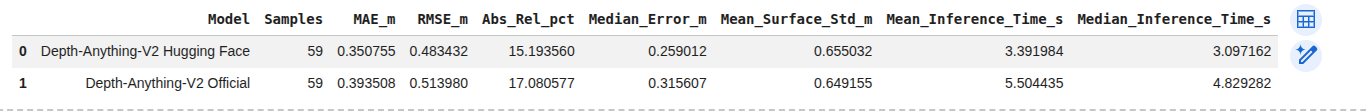

## Predicted Depth vs Ground Truth

The identity line represents ideal metric-depth estimation. Each point is one of the 59 real RGB-depth frames, plotting the RealSense ground-truth median depth against the predicted median depth for that frame.

Systematic deviation from this line can reveal scale bias, while scatter around the line reflects per-frame noise.


In [ ]:
plt.figure(figsize=(8, 7))

for model_name in comparison_df["Model"].unique():
    model_data = comparison_df[comparison_df["Model"] == model_name]
    plt.scatter(
        model_data["GT Median (m)"],
        model_data["Pred Median (m)"],
        alpha=0.7,
        label=model_name
    )

max_value = max(
    comparison_df["GT Median (m)"].max(),
    comparison_df["Pred Median (m)"].max()
)

plt.plot([0, max_value], [0, max_value], linestyle="--", color="black", label="Ideal Prediction")
plt.xlabel("Ground-Truth Median Depth (m)")
plt.ylabel("Predicted Median Depth (m)")
plt.title("Accuracy Across the Dataset")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8, 6))

for model_name in comparison_df["Model"].unique():
    model_data = comparison_df[comparison_df["Model"] == model_name].sort_values("Image")
    plt.plot(
        model_data["Image"].astype(str),
        model_data["MAE (m)"],
        marker="o",
        linestyle="",
        label=model_name
    )

plt.xlabel("Frame")
plt.ylabel("MAE (m)")
plt.title("Error Across the Dataset")
plt.xticks(rotation=90, fontsize=6)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Depth Map Visualization

These figures are qualitative. Quantitative conclusions should be based on the numerical tables and error plots rather than the appearance of a color map.


In [ ]:
case = available_cases[0]
key = case["image_number"]

gt_depth = np.array(Image.open(case["depth_path"]), dtype=np.float32) * DEPTH_UNITS_TO_METERS
gt_display = np.ma.masked_where(gt_depth <= 0, gt_depth)

maps = [
    ("Original RGB", np.asarray(case["image"]), None),
    ("RealSense Ground Truth", gt_display, "magma"),
    ("Official", official_depth_maps[key], "magma"),
    ("Hugging Face", hf_depth_maps[key], "magma")
]

if key in quant_depth_maps:
    maps.append(("4-bit NF4", quant_depth_maps[key], "magma"))

fig, axes = plt.subplots(1, len(maps), figsize=(6 * len(maps), 5))

if len(maps) == 1:
    axes = [axes]

for ax, (title, data, cmap) in zip(axes, maps):
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
    if cmap is not None:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## Interpretation

This evaluation compared the official Depth-Anything-V2 implementation with its Hugging Face Transformers implementation using the same 59 real RGB-depth pairs and the same dense RealSense ground-truth evaluation protocol.

The Hugging Face implementation outperformed the official implementation across all reported accuracy metrics. It achieved a lower mean MAE of 0.3508 m compared with 0.3935 m for the official implementation, while also achieving lower RMSE (0.4834 m vs. 0.5140 m), lower Abs Rel (15.19% vs. 17.08%), and lower median depth error (0.2590 m vs. 0.3156 m).

The Hugging Face implementation was also faster in the tested configuration, with a mean inference time of 3.39 s compared with 5.50 s for the official implementation. Its median latency was 3.10 s, compared with 4.83 s for the official implementation.

Therefore, under this experimental setup, the Hugging Face implementation provides both better measured depth accuracy and lower inference latency than the official Depth-Anything-V2 implementation. However, these results should be interpreted as an implementation-level comparison rather than evidence that the Hugging Face model is inherently superior, since differences in preprocessing, model configuration, execution path, and runtime environment can influence both accuracy and latency.

Overall, the experiment demonstrates that implementation choice can materially affect the practical behavior of the same model family, making it important to evaluate the actual deployment implementation rather than assuming that different implementations will produce identical results.


## Limitations

This is a controlled validation experiment rather than a comprehensive benchmark.

- The RealSense sensor itself can introduce noise and invalid pixels, so the "ground truth" is not perfect.
- The dataset is limited to a single lab environment.
- Only 59 RGB-depth pairs are included.
- RealSense depth degrades on reflective, transparent, distant, and low-texture surfaces, which propagates into the reported metrics.
- Accurate RGB-depth alignment is required for the pixel-level metrics to be meaningful.
- Quantization results depend strongly on GPU and software support.
- Latency is measured on whatever hardware ran the notebook and is not necessarily representative of target deployment hardware.
- A full deployment study should additionally report memory footprint, model size, throughput, and power consumption.
- Established datasets remain necessary for broad claims about generalization.


## Conclusion

This notebook evaluates Depth-Anything-V2 metric depth from monocular RGB images against **59 real RealSense RGB-depth pairs with dense, per-pixel ground truth**, across the official PyTorch, Hugging Face Transformers, and 4-bit quantized implementations.

Because ground truth is now a dense depth map rather than a single measured distance, the protocol supports both pixel-level accuracy metrics (MAE, RMSE, Abs Rel) and an image-level summary based on median depth, giving a more complete picture than a single scalar comparison.

**Workflow:**

**RealSense RGB-depth capture → RGB image → depth inference → dense predicted depth → pixel-wise comparison against RealSense ground truth → statistical analysis → runtime comparison**

This is a reproducible foundation that can be extended to more scenes, more implementations, and additional target hardware by adding further RGB-depth pairs to the same `color/` and `depth/` folder structure.
